In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [139]:
# suprafete vs pret
apartamente = np.array([ (30, 54_000), (36, 75_000), (49, 120_000), (53, 175_000),  (69, 193_000), (70, 215_000) , (79, 210_000), (83, 245_000), (84, 284_000), (90, 345_000) ])
suprafete = apartamente[:, 0]
preturi = apartamente[:, 1]

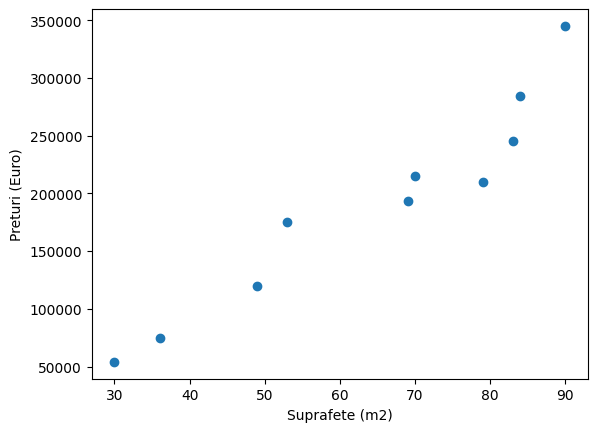

In [140]:
plt.scatter(suprafete, preturi);
plt.xlabel("Suprafete (m2)");
plt.ylabel("Preturi (Euro)");

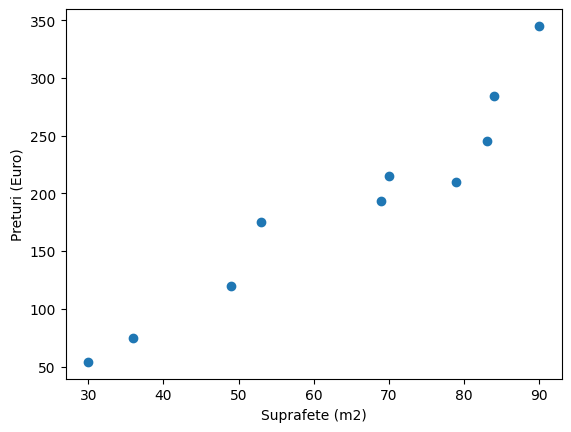

In [141]:
plt.scatter(suprafete, preturi / 1000);
plt.xlabel("Suprafete (m2)");
plt.ylabel("Preturi (Euro)");

In [142]:
n = len(suprafete)
n

10

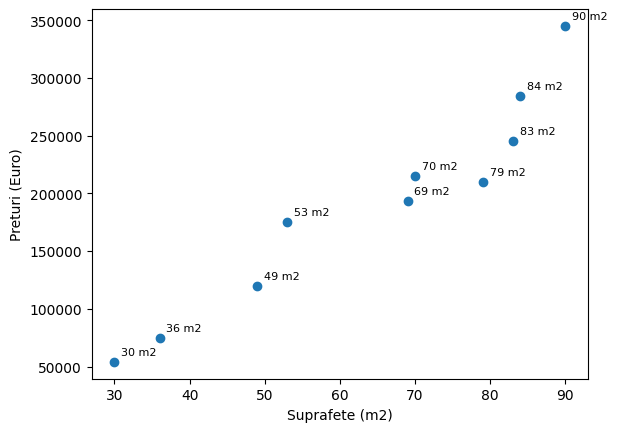

In [143]:
plt.scatter(suprafete, preturi );
plt.xlabel("Suprafete (m2)");
plt.ylabel("Preturi (Euro)");
for i in range(n):
    plt.annotate(f"{int(suprafete[i])} m2", (suprafete[i], preturi[i]), textcoords="offset points", xytext=(5, 5), fontsize=8)
plt.show()


In [144]:
x_raw = suprafete
y_raw = preturi

In [145]:
x_raw = x_raw.reshape(-1, 1).astype(float)
x_raw

array([[30.],
       [36.],
       [49.],
       [53.],
       [69.],
       [70.],
       [79.],
       [83.],
       [84.],
       [90.]])

In [146]:
y_raw = y_raw.reshape(-1, 1).astype(float)
y_raw

array([[ 54000.],
       [ 75000.],
       [120000.],
       [175000.],
       [193000.],
       [215000.],
       [210000.],
       [245000.],
       [284000.],
       [345000.]])

# Normalizarea datelor

In [147]:
x_mean = x_raw.mean()
x_mean



np.float64(64.3)

In [148]:
x_std = x_raw.std()
x_std

np.float64(20.020239758804088)

In [149]:
x_raw

array([[30.],
       [36.],
       [49.],
       [53.],
       [69.],
       [70.],
       [79.],
       [83.],
       [84.],
       [90.]])

In [150]:
y_mean = y_raw.mean() # media
y_std = y_raw.std() # deviatia standard

In [151]:
x = (x_raw - x_mean) / x_std
y = (y_raw - y_mean) / y_std


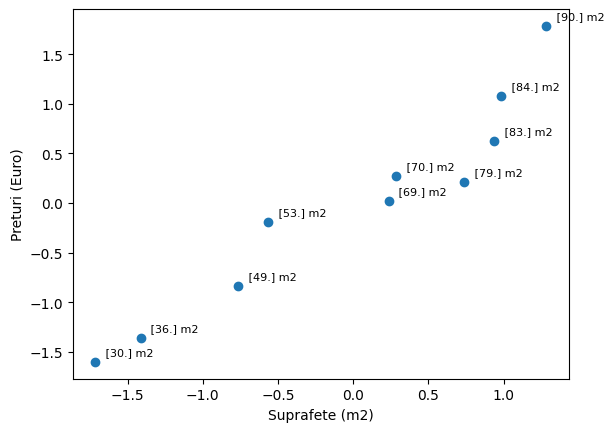

In [152]:
x_flatten = x.flatten()
y_flatten = y.flatten()

plt.scatter(x_flatten, y_flatten );
plt.xlabel("Suprafete (m2)");
plt.ylabel("Preturi (Euro)");
for i in range(n):
    plt.annotate(f" { x_raw[i].flatten() } m2", (x_flatten[i], y_flatten[i]), textcoords="offset points", xytext=(5, 5), fontsize=8)
plt.show()

In [153]:
pd.DataFrame({"x_raw":x_raw.flatten(), "x":x.flatten(), "y_raw":y_raw.flatten(), "y":y.flatten()})

,x_raw,x,y_raw,y
0,30.0,-1.713266,54000.0,-1.602381
1,36.0,-1.413569,75000.0,-1.357831
2,49.0,-0.764227,120000.0,-0.833797
3,53.0,-0.564429,175000.0,-0.193310
4,69.0,0.234762,193000.0,0.016303
5,70.0,0.284712,215000.0,0.272498
6,79.0,0.734257,210000.0,0.214272
7,83.0,0.934055,245000.0,0.621854
8,84.0,0.984004,284000.0,1.076017
9,90.0,1.283701,345000.0,1.786375


In [154]:
w0 = np.zeros(shape=(1, 1)) # shape (1, 1) -> un array cu 1 element in interior
w0

array([[0.]])

In [155]:
b0 = np.zeros(shape=(1, 1))

In [156]:
# Learning rate
alpha = 0.1  # De obicei sunt valori puteri ale lui 10 ( 0.1, 0.01, 0.001, 1, 10, 100)
epochs = 30 # (Cate rulari trebuie sa existe) -> de incercat si cu 10, 100, 10_000, 100_000





In [157]:
x

array([[-1.7132662 ],
       [-1.41356948],
       [-0.76422661],
       [-0.5644288 ],
       [ 0.23476242],
       [ 0.28471188],
       [ 0.73425694],
       [ 0.93405475],
       [ 0.9840042 ],
       [ 1.28370091]])

# @ - Operator de matrix multiplication (numpy)

In [158]:
y_pred = x @ w0 + b0
y_pred

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [159]:
y

array([[-1.60238064],
       [-1.35783127],
       [-0.8337969 ],
       [-0.19331046],
       [ 0.01630329],
       [ 0.27249787],
       [ 0.21427183],
       [ 0.62185411],
       [ 1.07601723],
       [ 1.78637493]])

In [160]:
errori0 = y_pred - y
errori0

array([[ 1.60238064],
       [ 1.35783127],
       [ 0.8337969 ],
       [ 0.19331046],
       [-0.01630329],
       [-0.27249787],
       [-0.21427183],
       [-0.62185411],
       [-1.07601723],
       [-1.78637493]])

In [161]:
x

array([[-1.7132662 ],
       [-1.41356948],
       [-0.76422661],
       [-0.5644288 ],
       [ 0.23476242],
       [ 0.28471188],
       [ 0.73425694],
       [ 0.93405475],
       [ 0.9840042 ],
       [ 1.28370091]])

In [162]:
x.T # Transpus (matrice transpusa)

array([[-1.7132662 , -1.41356948, -0.76422661, -0.5644288 ,  0.23476242,
         0.28471188,  0.73425694,  0.93405475,  0.9840042 ,  1.28370091]])

In [163]:
# grad_a = (2/n) * np.sum(errros * x_norm)
# grad_b = (2/n) * np.sum(errros)

# a_gd = a_gd - alpha * grad_a
# ## Noul b
# b_gd = b_gd - alpha * grad_b


grad_w0 = (2 / n) * ( errori0 @ x.T )
grad_b0 = (2 / n) * np.sum(errori0)

# calculez noile valori
w0 = w0 - alpha * grad_w0
b0 = b0 - alpha * grad_b0




# Calculam valorile intr-un numar de epoci

In [164]:
x.shape, w0.shape

((10, 1), (10, 10))

In [165]:
alpha = 0.1  # De obicei sunt valori puteri ale lui 10 ( 0.1, 0.01, 0.001, 1, 10, 100)
epochs = 1000 # (Cate rulari trebuie sa existe) -> de incercat si cu 10, 100, 10_000, 100_000

# valorile initiale
w0 = np.zeros(shape=(1, 1)) # shape (1, 1) -> un array cu 1 element in interior
b0 = np.zeros(shape=(1, 1))

for i in range(epochs):
    ## forward
    y_pred = x @ w0 + b0
    
    ## barckwards - propagation
    errori0 = y_pred - y

    ## Calculare derivate
    grad_w0 = (2 / n) * ( x.T  @ errori0  )
    grad_b0 = (2 / n) * np.sum(errori0)

    # Ajustarea noilor valorile ale weights (greutati)
    w0 = w0 - alpha * grad_w0
    b0 = b0 - alpha * grad_b0

In [166]:
w0

array([[0.95825769]])

In [167]:
y_std

np.float64(85872.23066859275)

In [168]:
x_std

np.float64(20.020239758804088)

In [169]:
panta = (y_std / x_std ) * w0.flatten().flatten()
panta

array([4110.22679075])

In [170]:
b0

array([[-1.08801856e-16]])

In [171]:
intercept = y_mean + b0[0,0] * y_std - panta
intercept

array([187489.77320925])